<a href="https://colab.research.google.com/github/milkpotato1000/bigCon_hom/blob/jin2/bigcon_jin1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분석 개요

분석 목표 등 요약

데이터 정의서 등 참고 문서
- https://docs.google.com/spreadsheets/d/1Xepbio9MctRbELhnMcaqg9ln--wRQMYTL5g0wgS02wc/edit?gid=1092014041#gid=1092014041

# 데이터 로드

In [4]:
import numpy as np
import pandas as pd
import os

# 코랩 구글 드라이브용 경로
try:
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='cp949')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='cp949')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='cp949')
except UnicodeDecodeError:
    print("Could not decode using cp949, trying utf-8")
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='utf-8')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='utf-8')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='utf-8')


# 로컬용 경로

# 캐글용 경로
# train_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/train.csv')
# test_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/test.csv')

In [2]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4185 non-null   object 
 1   MCT_BSE_AR          4185 non-null   object 
 2   MCT_NM              4185 non-null   object 
 3   MCT_BRD_NUM         542 non-null    object 
 4   MCT_SIGUNGU_NM      4185 non-null   object 
 5   HPSN_MCT_ZCD_NM     4185 non-null   object 
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object 
 7   ARE_D               4185 non-null   int64  
 8   MCT_ME_D            127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [3]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ENCODED_MCT             86590 non-null  object 
 1   TA_YM                   86590 non-null  int64  
 2   MCT_OPE_MS_CN           86590 non-null  object 
 3   RC_M1_SAA               86590 non-null  object 
 4   RC_M1_TO_UE_CT          86590 non-null  object 
 5   RC_M1_UE_CUS_CN         86590 non-null  object 
 6   RC_M1_AV_NP_AT          86590 non-null  object 
 7   APV_CE_RAT              79958 non-null  object 
 8   DLV_SAA_RAT             86590 non-null  float64
 9   M1_SME_RY_SAA_RAT       86590 non-null  float64
 10  M1_SME_RY_CNT_RAT       86590 non-null  float64
 11  M12_SME_RY_SAA_PCE_RT   86590 non-null  float64
 12  M12_SME_BZN_SAA_PCE_RT  86590 non-null  float64
 13  M12_SME_RY_ME_MCT_RAT   86590 non-null  float64
 14  M12_SME_BZN_ME_MCT_RAT  86590 non-null

In [4]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  int64  
 2   M12_MAL_1020_RAT          86590 non-null  float64
 3   M12_MAL_30_RAT            86590 non-null  float64
 4   M12_MAL_40_RAT            86590 non-null  float64
 5   M12_MAL_50_RAT            86590 non-null  float64
 6   M12_MAL_60_RAT            86590 non-null  float64
 7   M12_FME_1020_RAT          86590 non-null  float64
 8   M12_FME_30_RAT            86590 non-null  float64
 9   M12_FME_40_RAT            86590 non-null  float64
 10  M12_FME_50_RAT            86590 non-null  float64
 11  M12_FME_60_RAT            86590 non-null  float64
 12  MCT_UE_CLN_REU_RAT        86590 non-null  float64
 13  MCT_UE_CLN_NEW_RAT        86590 non-null  float64
 14  RC_M1_

In [5]:
df1.head(5)

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN


In [6]:
df2.head(5)

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [7]:
df3.head(5)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [8]:
df1['MCT_BSE_AR'].value_counts()

,count
MCT_BSE_AR,
서울특별시 성동구 왕십리로 410,73
서울특별시 성동구 마장로 137,38
서울특별시 성동구 왕십리광장로 17,31
서울 성동구 마장동,21
서울특별시 성동구 무학로6길 50,18
...,...
서울특별시 성동구 장터길 45,1
서울특별시 성동구 장터길 47,1
서울특별시 성동구 행당로 43,1


In [9]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts()

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [10]:
df2['MCT_OPE_MS_CN'].value_counts()

,count
MCT_OPE_MS_CN,
3_25-50%,21812
4_50-75%,21567
5_75-90%,13454
2_10-25%,13119
1_10%이하,8691
6_90%초과(하위 10% 이하),7947


### df1 형별

In [11]:
object_columns = df1.select_dtypes(include='object').columns.tolist()
numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Object Columns:", object_columns)
print("Numeric Columns:", numeric_columns)

Object Columns: ['ENCODED_MCT', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM', 'HPSN_MCT_BZN_CD_NM']
Numeric Columns: ['ARE_D', 'MCT_ME_D']


/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

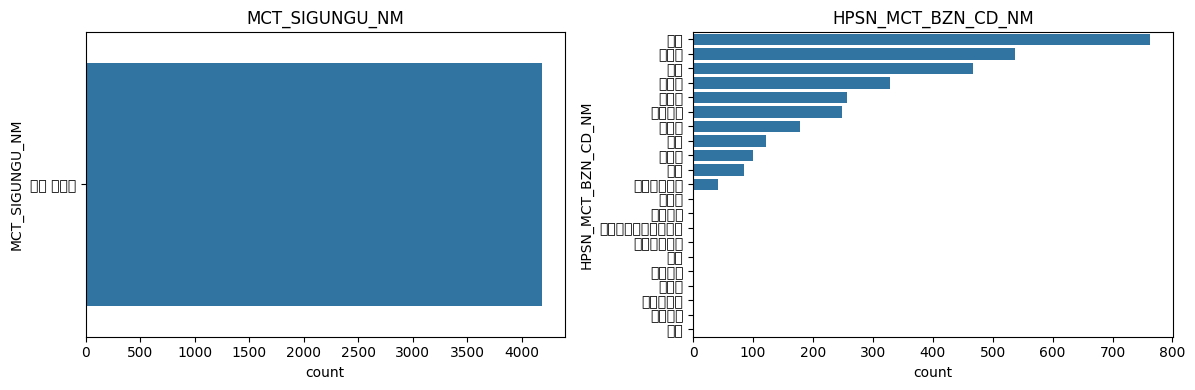

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
object_columns_to_plot = [col for col in object_columns if df1[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df1, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

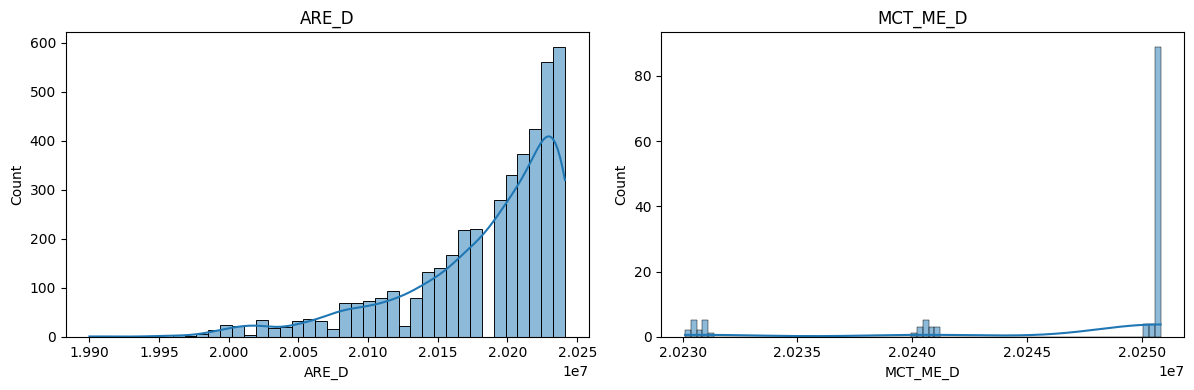

In [13]:
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    if df1[col].nunique() > 50:  # Use histogram for columns with many unique values
        sns.histplot(data=df1, x=col, kde=True)
    else:  # Use countplot or barplot for columns with few unique values
        sns.countplot(data=df1, y=col, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

### df2 형별

In [14]:
df2_object_columns = df2.select_dtypes(include='object').columns.tolist()
df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df2 Object Columns:", df2_object_columns)
print("df2 Numeric Columns:", df2_numeric_columns)

df2 Object Columns: ['ENCODED_MCT', 'MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT']
df2 Numeric Columns: ['TA_YM', 'DLV_SAA_RAT', 'M1_SME_RY_SAA_RAT', 'M1_SME_RY_CNT_RAT', 'M12_SME_RY_SAA_PCE_RT', 'M12_SME_BZN_SAA_PCE_RT', 'M12_SME_RY_ME_MCT_RAT', 'M12_SME_BZN_ME_MCT_RAT']


NanumGothic font not found.


/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

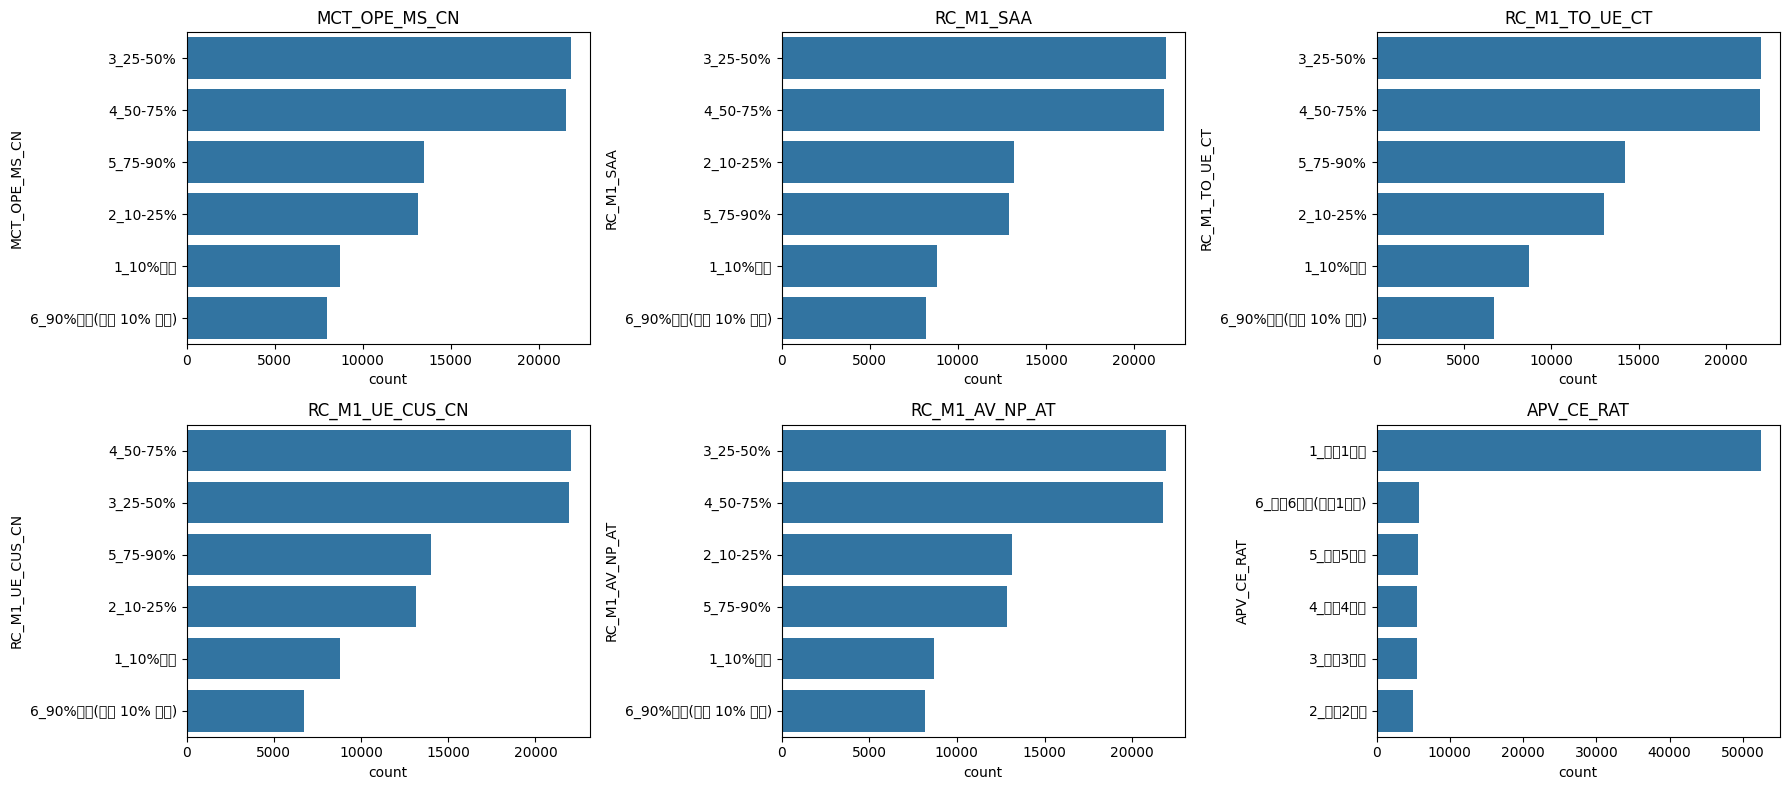

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# Find the Nanum font file
nanum_font_path = None
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'NanumGothic' in font_path:
        nanum_font_path = font_path
        break

if nanum_font_path:
    # Add the font to matplotlib's font manager
    fm.fontManager.addfont(nanum_font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("NanumGothic font not found.")
    # Fallback to a default font if NanumGothic is not found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True


# Filter out columns with too many unique values for plotting
df2_object_columns_to_plot = [col for col in df2_object_columns if df2[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df2_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df2_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df2, order=df2[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.font_manager as fm

# # Find available Korean fonts and set font
# font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
# korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

# if len(korean_font_list) > 0:
#     # Use the first found Korean font
#     plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
#     plt.rcParams['axes.unicode_minus'] = False
#     print(f"Using font: {plt.rcParams['font.family']}")
# else:
#     print("No Korean fonts found on the system.")
#     # Fallback to a default font if no Korean font is found
#     plt.rcParams['font.family'] = 'DejaVu Sans'
#     plt.rcParams['axes.unicode_minus'] = True

# # Identify numeric columns in df2 (assuming df2_numeric_columns is already defined)
# df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

# n_cols = 3
# n_rows = (len(df2_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df2_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df2[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df2, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df2, y=col, order=df2[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

No Korean fonts found on the system.



KeyboardInterrupt



### df3 형별

In [10]:
df3_object_columns = df3.select_dtypes(include='object').columns.tolist()
df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df3 Object Columns:", df3_object_columns)
print("df3 Numeric Columns:", df3_numeric_columns)

df3 Object Columns: ['ENCODED_MCT']
df3 Numeric Columns: ['TA_YM', 'M12_MAL_1020_RAT', 'M12_MAL_30_RAT', 'M12_MAL_40_RAT', 'M12_MAL_50_RAT', 'M12_MAL_60_RAT', 'M12_FME_1020_RAT', 'M12_FME_30_RAT', 'M12_FME_40_RAT', 'M12_FME_50_RAT', 'M12_FME_60_RAT', 'MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT', 'RC_M1_SHC_RSD_UE_CLN_RAT', 'RC_M1_SHC_WP_UE_CLN_RAT', 'RC_M1_SHC_FLP_UE_CLN_RAT']


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
df3_object_columns_to_plot = [col for col in df3_object_columns if df3[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df3_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df3_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df3, order=df3[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

<Figure size 1800x0 with 0 Axes>

In [7]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Identify numeric columns in df3 (assuming df3_numeric_columns is already defined)
# df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()


# n_cols = 3
# n_rows = (len(df3_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df3_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df3[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df3, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df3, y=col, order=df3[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x798ee16e8cc0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x798ee16b2200> (for post_execute):


KeyboardInterrupt: 

## 결측치 확인

In [12]:
# Check for missing values in df1 and calculate the percentage
missing_df1 = df1.isnull().sum()
missing_percent_df1 = (missing_df1 / len(df1)) * 100
missing_info_df1 = pd.DataFrame({'Missing Count': missing_df1, 'Missing Percentage': missing_percent_df1})
missing_info_df1 = missing_info_df1[missing_info_df1['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df2 and calculate the percentage
missing_df2 = df2.isnull().sum()
missing_percent_df2 = (missing_df2 / len(df2)) * 100
missing_info_df2 = pd.DataFrame({'Missing Count': missing_df2, 'Missing Percentage': missing_percent_df2})
missing_info_df2 = missing_info_df2[missing_info_df2['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df3 and calculate the percentage
missing_df3 = df3.isnull().sum()
missing_percent_df3 = (missing_df3 / len(df3)) * 100
missing_info_df3 = pd.DataFrame({'Missing Count': missing_df3, 'Missing Percentage': missing_percent_df3})
missing_info_df3 = missing_info_df3[missing_info_df3['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in df1:")
display(missing_info_df1)

print("\nMissing values in df2:")
display(missing_info_df2)

print("\nMissing values in df3:")
display(missing_info_df3)

Missing values in df1:


,Missing Count,Missing Percentage
MCT_ME_D,4058,96.965352
MCT_BRD_NUM,3643,87.048984
HPSN_MCT_BZN_CD_NM,1047,25.017921



Missing values in df2:


,Missing Count,Missing Percentage
APV_CE_RAT,6632,7.659083



Missing values in df3:


,Missing Count,Missing Percentage


No Korean fonts found on the system.


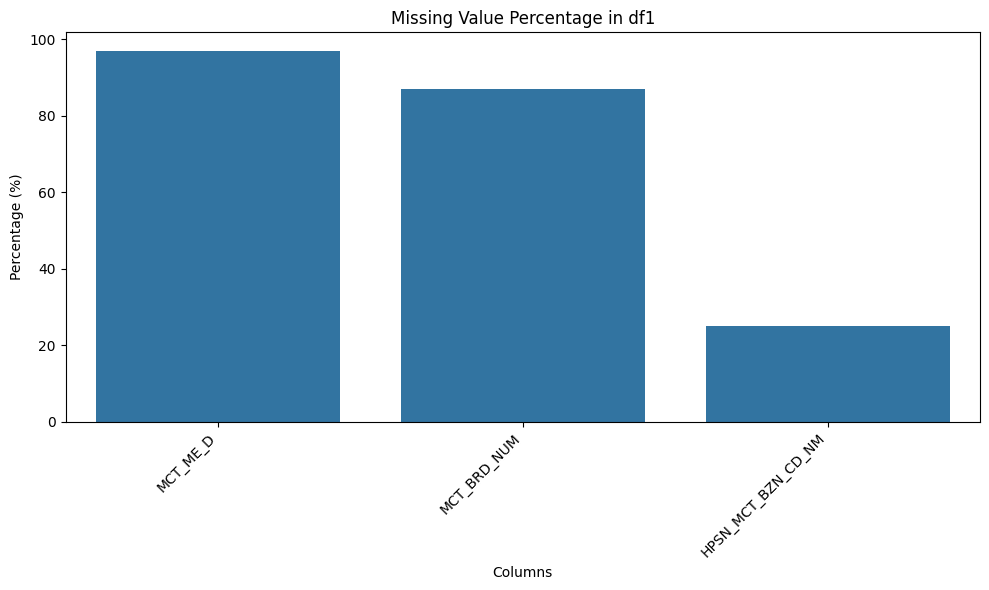

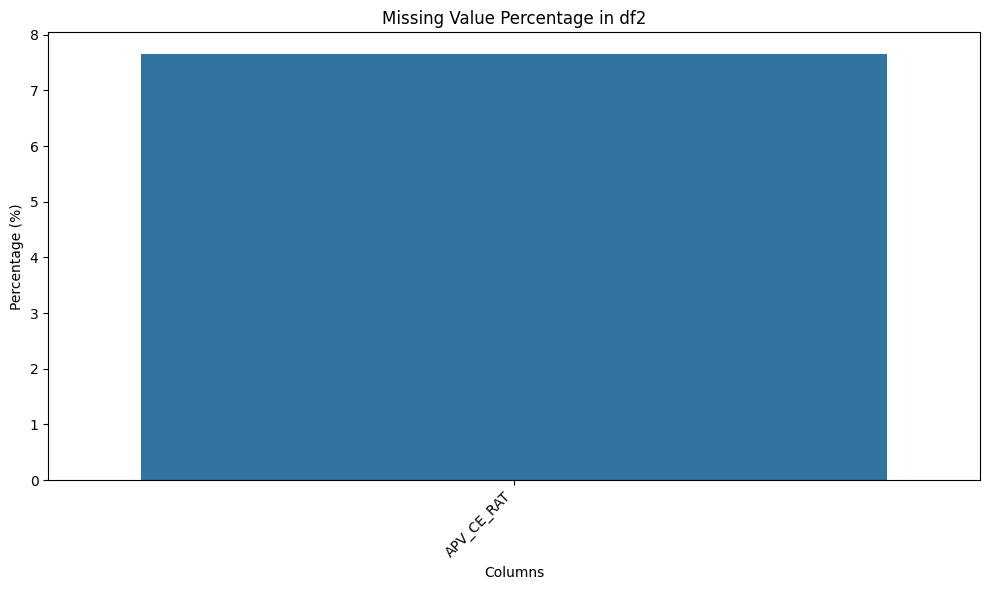

No missing values to plot for df3.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Find available Korean fonts and set font
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

if len(korean_font_list) > 0:
    # Use the first found Korean font
    plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("No Korean fonts found on the system.")
    # Fallback to a default font if no Korean font is found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True

# Plot missing values for df1
if not missing_info_df1.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df1.index, y='Missing Percentage', data=missing_info_df1)
    plt.title('Missing Value Percentage in df1')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df1.")

# Plot missing values for df2
if not missing_info_df2.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df2.index, y='Missing Percentage', data=missing_info_df2)
    plt.title('Missing Value Percentage in df2')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df2.")

# Plot missing values for df3
if not missing_info_df3.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df3.index, y='Missing Percentage', data=missing_info_df3)
    plt.title('Missing Value Percentage in df3')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df3.")

## 기초 통계량

In [14]:
# Calculate and display basic statistics for numeric columns in df1
print("Basic statistics for numeric columns in df1:")
display(df1.describe())

# Calculate and display basic statistics for numeric columns in df2
print("\nBasic statistics for numeric columns in df2:")
display(df2.describe())

# Calculate and display basic statistics for numeric columns in df3
print("\nBasic statistics for numeric columns in df3:")
display(df3.describe())

Basic statistics for numeric columns in df1:


,ARE_D,MCT_ME_D
count,4.185000e+03,1.270000e+02
mean,2.018352e+07,2.024716e+07
std,5.743071e+04,6.859542e+03
min,1.990023e+07,2.023010e+07
25%,2.016032e+07,2.025017e+07
50%,2.020073e+07,2.025072e+07
75%,2.023033e+07,2.025080e+07
max,2.024122e+07,2.025082e+07



Basic statistics for numeric columns in df2:


,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-662249.470344,134.503306,152.312380,31.184643,24.070313,16.187137,-247354.685375
std,49.948354,472955.612921,167.981671,227.070665,25.253279,22.843491,3.876532,431484.515919
min,202301.000000,-999999.900000,-70.000000,0.000000,0.100000,0.000000,0.000000,-999999.900000
25%,202307.000000,-999999.900000,25.200000,22.100000,9.900000,1.300000,14.100000,4.200000
50%,202401.000000,-999999.900000,82.500000,81.700000,23.900000,18.900000,17.000000,8.000000
75%,202407.000000,3.400000,181.700000,199.600000,48.200000,39.200000,18.700000,9.000000
max,202412.000000,111.200000,4300.900000,7059.800000,100.000000,99.600000,59.100000,13.900000



Basic statistics for numeric columns in df3:


,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-23132.288511,-23130.483150,-23133.699739,-23132.727377,-23134.757761,-23132.931257,-23132.508397,-23135.875375,-23135.667261,-23136.852116,-18949.612306,-18964.829428,-84585.222446,-84605.088521,-84569.608085
std,49.948354,150361.910036,150362.187842,150361.692698,150361.842481,150361.530077,150361.811198,150361.876105,150361.357768,150361.389830,150361.207660,136439.003444,136436.887054,278322.440389,278316.399644,278327.187716
min,202301.000000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000
25%,202307.000000,3.744925,7.509725,4.889600,4.441050,1.464000,2.272000,5.232150,4.171050,4.088000,1.358550,13.820000,4.970000,10.400000,1.100000,30.300000
50%,202401.000000,9.637500,12.284000,9.258800,8.795350,4.818600,6.802500,9.657850,6.669800,6.579150,3.369250,24.030000,6.700000,28.100000,7.600000,48.000000
75%,202407.000000,15.903450,17.985750,13.299000,14.926850,12.045925,15.247550,15.748650,9.725000,10.098000,7.451300,33.750000,8.780000,50.000000,17.100000,66.300000
max,202412.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


## 이상치 확인

Box plots for df1 numeric columns:


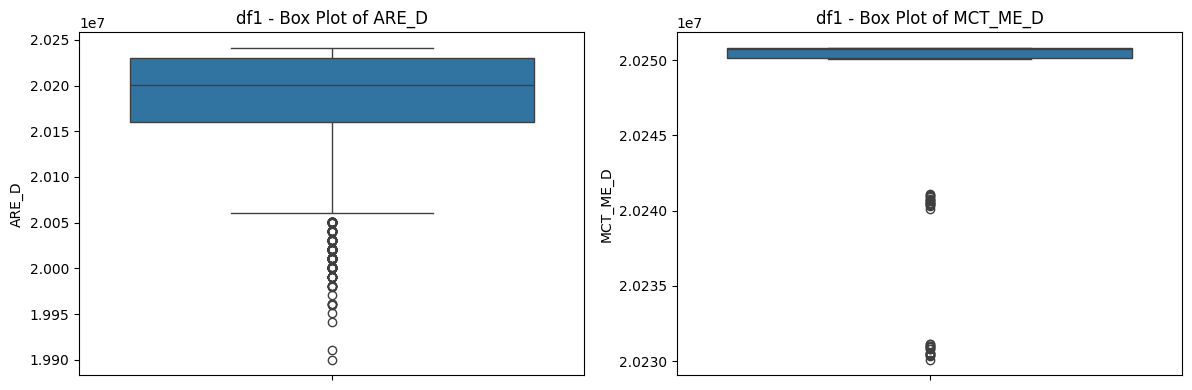


Box plots for df2 numeric columns:


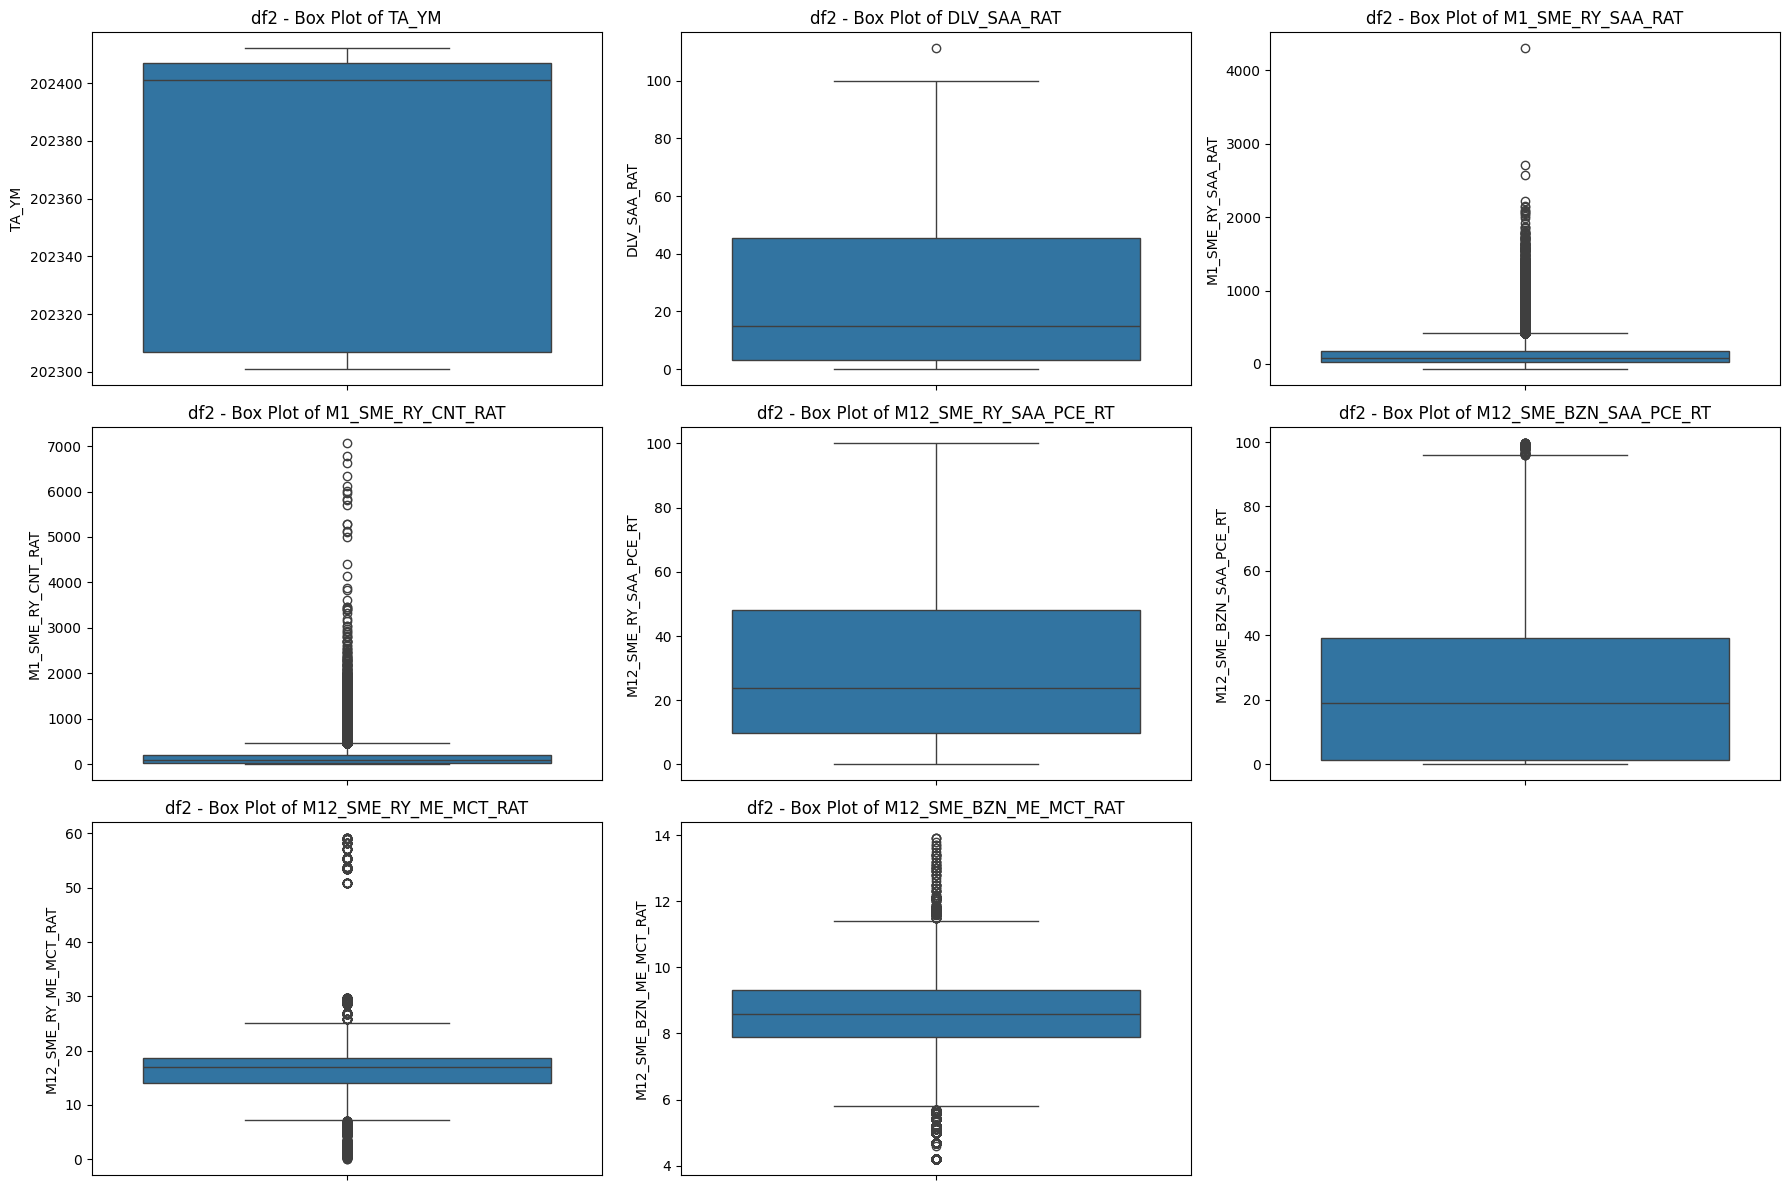


Box plots for df3 numeric columns:


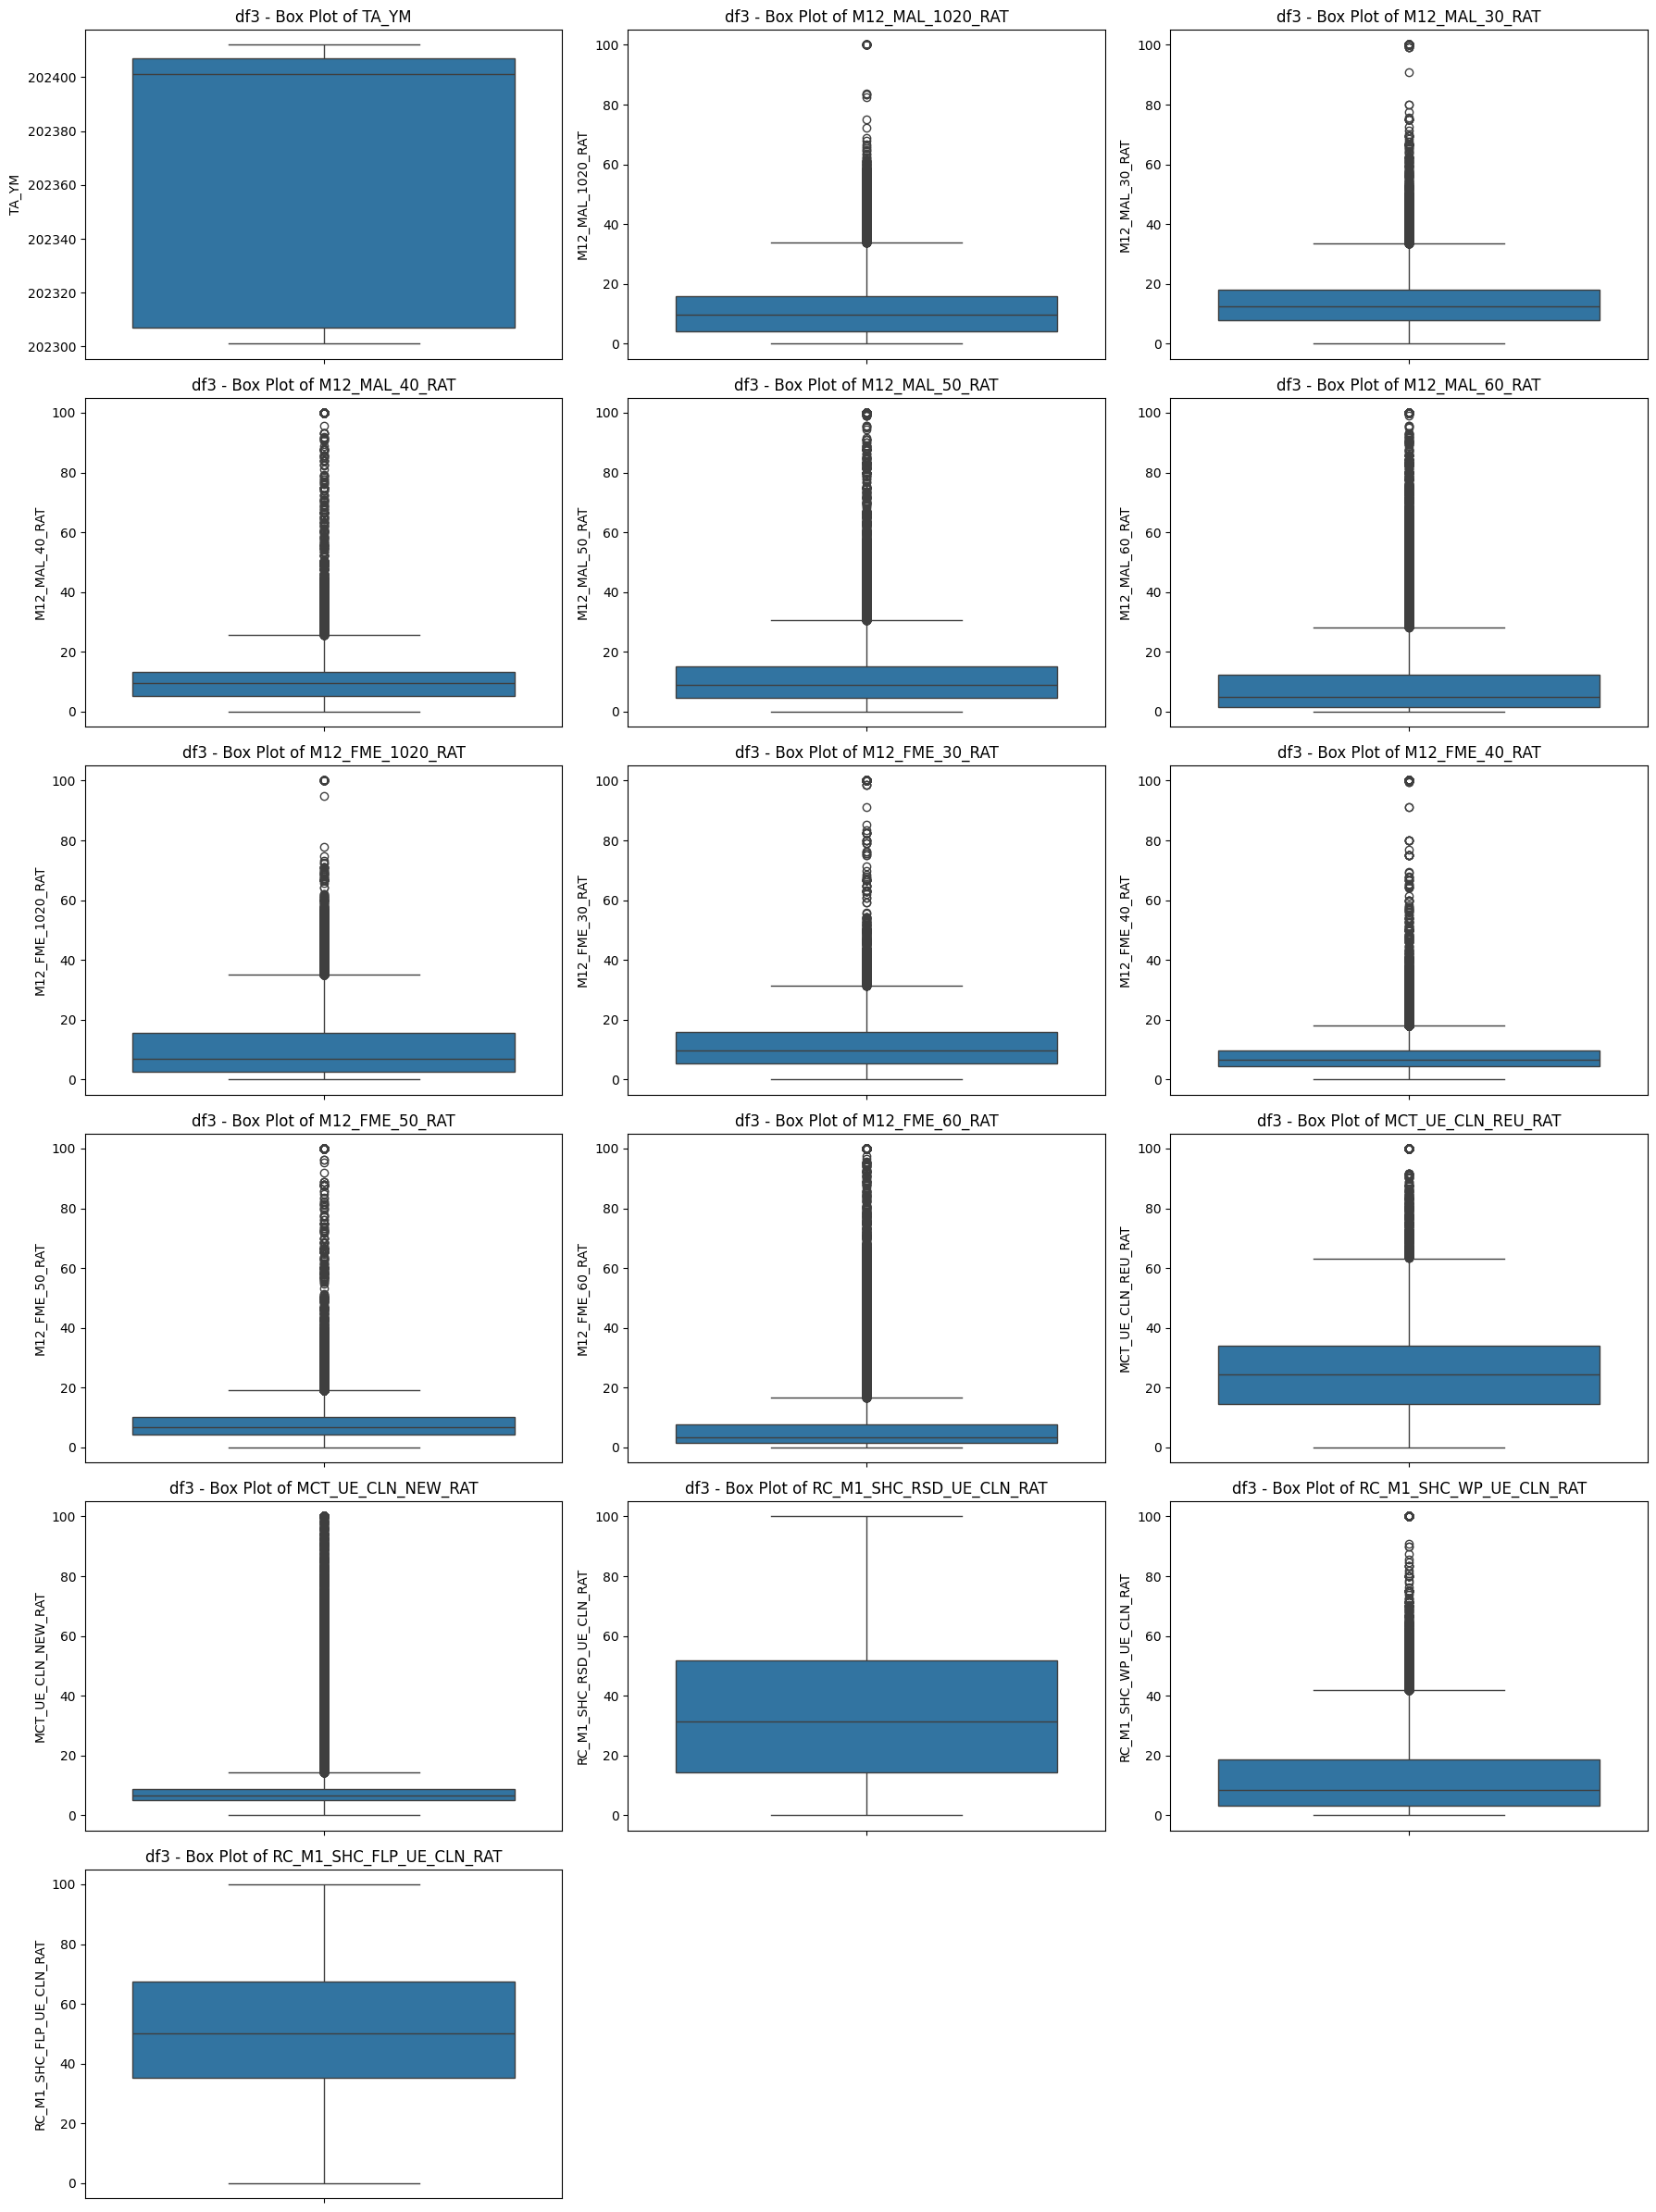

In [15]:
# Get the list of numeric columns for each dataframe
df1_numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()
df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Function to create box plots for numeric columns, handling placeholder values
def plot_numeric_boxplot(df, numeric_cols, df_name):
    # Replace placeholder value with NaN for plotting purposes
    df_cleaned = df.replace(-999999.9, np.nan)

    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 6, n_rows * 4))

    for i, col in enumerate(numeric_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(data=df_cleaned, y=col)
        plt.title(f'{df_name} - Box Plot of {col}')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# Plot box plots for numeric columns in each dataframe
print("Box plots for df1 numeric columns:")
plot_numeric_boxplot(df1, df1_numeric_columns, 'df1')

print("\nBox plots for df2 numeric columns:")
plot_numeric_boxplot(df2, df2_numeric_columns, 'df2')

print("\nBox plots for df3 numeric columns:")
plot_numeric_boxplot(df3, df3_numeric_columns, 'df3')

## 상관 관계 분석

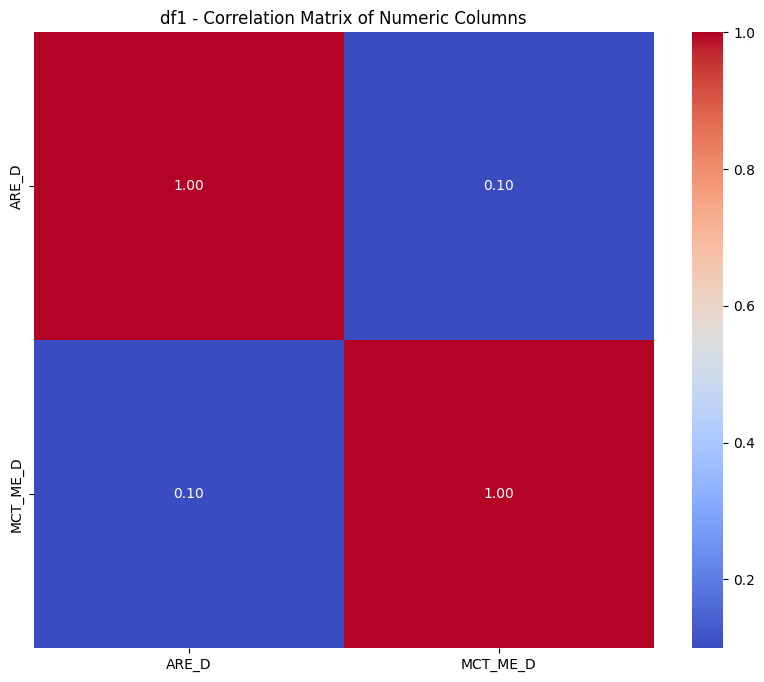

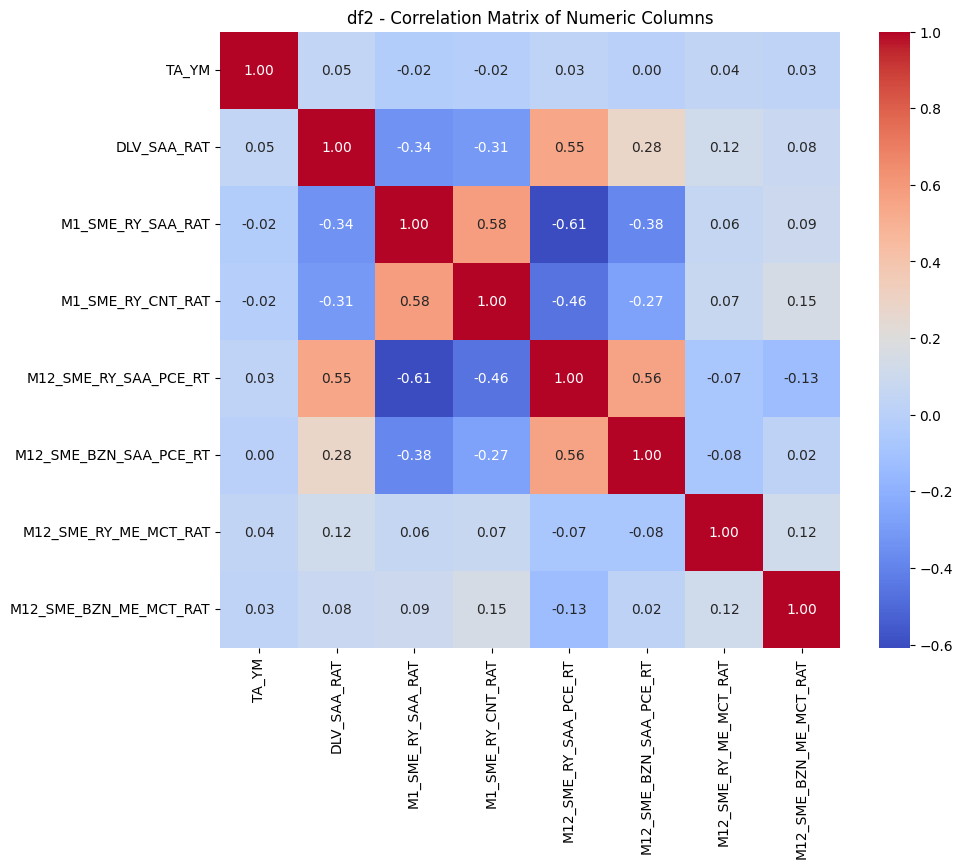

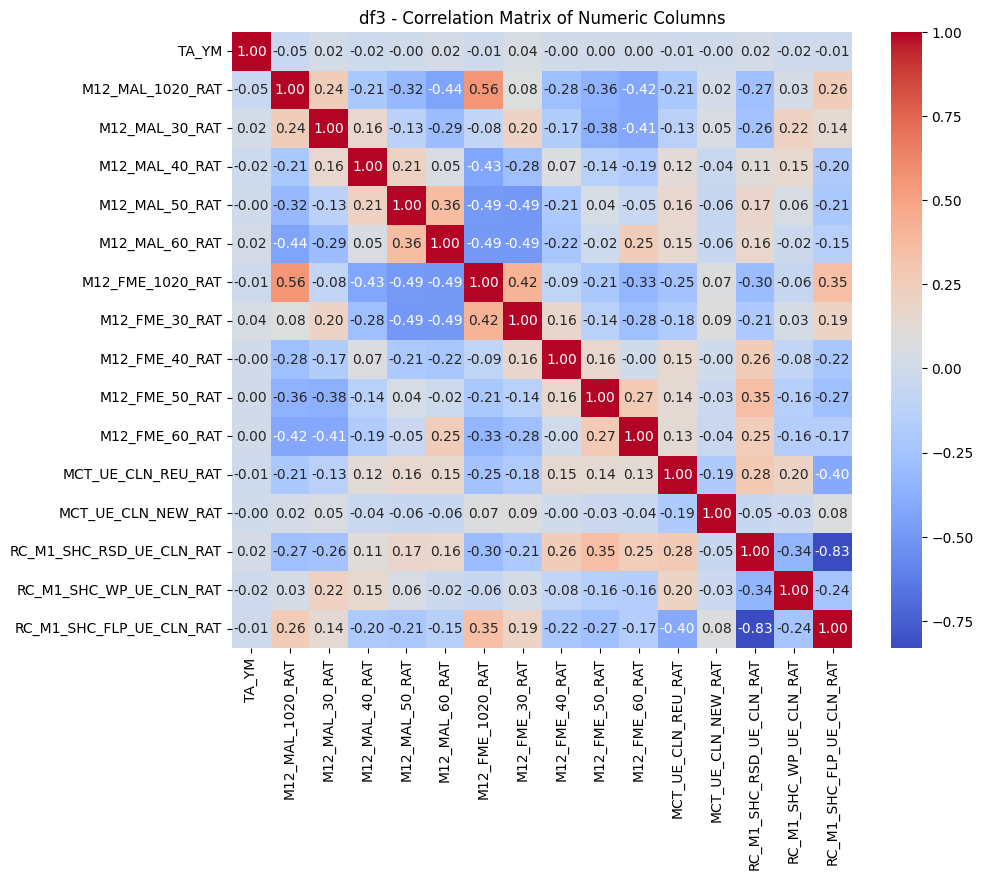

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate and plot correlation matrix, handling placeholder values
def plot_correlation_heatmap(df, df_name):
    # Select numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

    # Replace placeholder value with NaN before calculating correlation
    numeric_df = numeric_df.replace(-999999.9, np.nan)

    # Drop columns with all NaN values after replacing placeholder
    numeric_df = numeric_df.dropna(axis=1, how='all')

    if numeric_df.shape[1] > 1:
        # Calculate the correlation matrix
        correlation_matrix = numeric_df.corr()

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'{df_name} - Correlation Matrix of Numeric Columns')
        plt.show()
    else:
        print(f"DataFrame {df_name} does not have enough numeric columns (after handling placeholders) to calculate correlation.")


# Plot correlation heatmap for each dataframe
plot_correlation_heatmap(df1, 'df1')
plot_correlation_heatmap(df2, 'df2')
plot_correlation_heatmap(df3, 'df3')